In [1]:
import sys

# Load github repo
!git clone https://github.com/erezpoliak/AnimalClassifier

sys.path.append('/content/AnimalClassifier/EX4 - Project')

Cloning into 'AnimalClassifier'...
remote: Enumerating objects: 2049, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 2049 (delta 41), reused 61 (delta 15), pack-reused 1962 (from 2)
Receiving objects: 100% (2049/2049), 44.98 MiB | 36.94 MiB/s, done.
Resolving deltas: 100% (42/42), done.


In [2]:
from torchvision import datasets, transforms

# Download CIFAR-10 dataset
cifar_train = datasets.CIFAR10(root='./data_cifar', train=True, download=True, transform=transforms.ToTensor())
cifar_test = datasets.CIFAR10(root='./data_cifar', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:01<00:00, 100MB/s]


# Data Exploration

In [3]:
# Basic Info

print(f'CIFAR-10 Train Size: {len(cifar_train)}')
print(f'CIFAR-10 Test Size: {len(cifar_test)}')
print(f'CIFAR-10 Classes: {cifar_train.classes}')
print(f'CIFAR-10 Classes Count: {len(cifar_train.classes)}')
print(f'CIFAR-10 Image Shape: {cifar_train[0][0].shape}')

CIFAR-10 Train Size: 50000
CIFAR-10 Test Size: 10000
CIFAR-10 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR-10 Classes Count: 10
CIFAR-10 Image Shape: torch.Size([3, 32, 32])


In [4]:
# Class Distribution
from dataset_util import display_class_distribution

display_class_distribution(cifar_train)

frog: 5000
truck: 5000
deer: 5000
automobile: 5000
bird: 5000
horse: 5000
ship: 5000
cat: 5000
dog: 5000
airplane: 5000


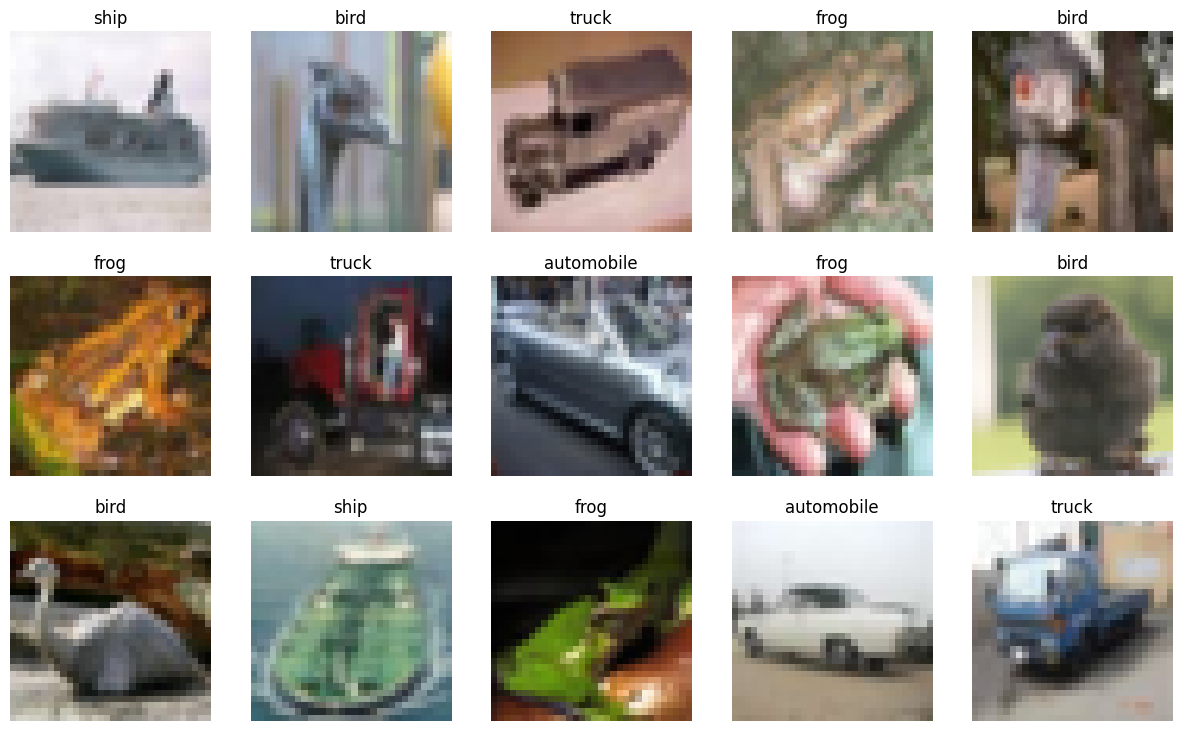

In [5]:
# Visualize few image samples
from dataset_util import display_image_samples

display_image_samples(cifar_train)

## Why CIFAR-10 for Transfer Learning?

**Dataset Relevance:**
- 6 overlapping classes with our dataset: bird, cat, deer, dog, horse, frog
- Natural images with similar visual patterns (textures, shapes, backgrounds)

**Transferable Features:**
- **Low-level**: Edge detection, texture patterns (fur/feathers), color gradients
- **Mid-level**: Body part detection (legs, heads, tails), shape recognition
- **High-level**: Animal vs non-animal discrimination, species characteristics

**Why This Helps:**
CIFAR-10's 50k images teach robust feature detectors. Even at lower resolution (32×32), convolutional filters learn transferable patterns that work on our higher resolution (224×224) animal images. Expected benefits: faster convergence and better generalization on our small (~2000 image) dataset.

# Pretraining on CIFAR-10

In [7]:
# Normalizing + Augmenting
from dataset_util import calculate_normalization_stats, get_normalized_transforms

mean_cifar, std_cifar = calculate_normalization_stats(cifar_train)
print(f'CIFAR-10 Mean: {mean_cifar}')
print(f'CIFAR-10 Std: {std_cifar}')

# Create transforms with augmentation only for train
train_transform_cifar = get_normalized_transforms(mean_cifar, std_cifar, input_size = 32, augment = True)
val_transform_cifar = get_normalized_transforms(mean_cifar, std_cifar, input_size = 32, augment = False)

# Load CIFAR-10 with transforms
cifar_train_transformed = datasets.CIFAR10(root='./data_cifar', train=True, download=False, transform=train_transform_cifar)
cifar_val_transformed = datasets.CIFAR10(root='./data_cifar', train=True, download=False, transform=val_transform_cifar)
cifar_test_transformed = datasets.CIFAR10(root='./data_cifar', train=False, download=False, transform=val_transform_cifar)

CIFAR-10 Mean: [0.491400808095932, 0.48215898871421814, 0.44653093814849854]
CIFAR-10 Std: [0.24703224003314972, 0.24348513782024384, 0.26158785820007324]


In [8]:
# Split to train/val/test
from torch.utils.data import Subset
import numpy as np

train_indices = list(range(45000))
val_indices = list(range(45000, 50000))

cifar_train = Subset(cifar_train_transformed, train_indices)
cifar_val = Subset(cifar_val_transformed, val_indices)

In [9]:
# Model architecture from last notebook

BATCH_SIZE = 32
LR = 0.001
CONV = [32, 64, 128, 256]
FC = [512, 256]
EPOCHS = 50
PATIENCE = 10
WEIGHT_DECAY = 0.001
DROPOUT = 0.2

In [10]:
import torch

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### Train And Evaluate

In [11]:
# Train on CIFAR-10
from model_util import train
from CustomCNN import CustomCNN


print('Pretraining on CIFAR-10')

cifar_train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=BATCH_SIZE, shuffle=True)
cifar_val_loader = torch.utils.data.DataLoader(cifar_val, batch_size=BATCH_SIZE, shuffle=False)
cifar_test_loader = torch.utils.data.DataLoader(cifar_test_transformed, batch_size=BATCH_SIZE, shuffle=False)

n_classes = 10
input_size = 32

cifar_model = CustomCNN(CONV, FC, input_size, n_classes, DROPOUT)
optimizer = torch.optim.Adam(cifar_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

cifar_model, history_cifar = train(cifar_model, cifar_train_loader, cifar_val_loader, optimizer, EPOCHS, PATIENCE, device)

Pretraining on CIFAR-10
Epoch 1/50 - Train Loss: 1.5469 - Train Acc: 0.4393 - Val Loss: 1.2413 - Val Acc: 0.5582
Epoch 5/50 - Train Loss: 0.8388 - Train Acc: 0.7130 - Val Loss: 0.8121 - Val Acc: 0.7314
Epoch 10/50 - Train Loss: 0.7014 - Train Acc: 0.7626 - Val Loss: 0.6433 - Val Acc: 0.7814
Epoch 15/50 - Train Loss: 0.6472 - Train Acc: 0.7802 - Val Loss: 0.6314 - Val Acc: 0.7880
Epoch 20/50 - Train Loss: 0.6183 - Train Acc: 0.7914 - Val Loss: 0.5838 - Val Acc: 0.7988
Epoch 25/50 - Train Loss: 0.5984 - Train Acc: 0.7972 - Val Loss: 0.6099 - Val Acc: 0.7940
Epoch 30/50 - Train Loss: 0.5864 - Train Acc: 0.8025 - Val Loss: 0.6036 - Val Acc: 0.8042
Epoch 35/50 - Train Loss: 0.5739 - Train Acc: 0.8091 - Val Loss: 0.5981 - Val Acc: 0.7978
Epoch 40/50 - Train Loss: 0.5699 - Train Acc: 0.8093 - Val Loss: 0.5889 - Val Acc: 0.7990
Early stopping at epoch 43


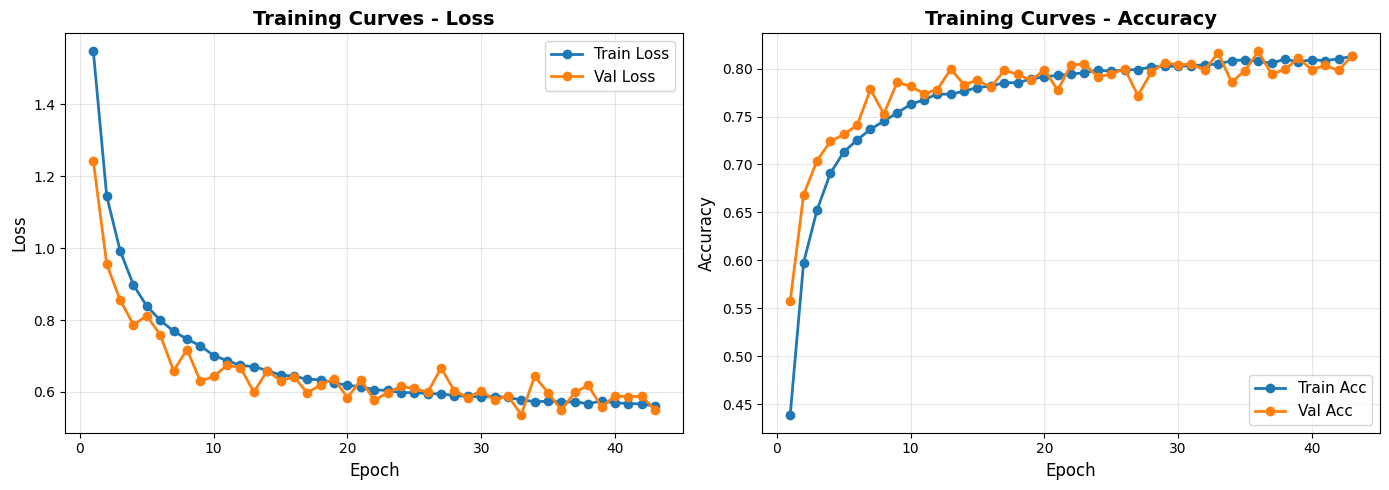

In [12]:
# Plot Training Curves
from model_util import plot_training_curves

plot_training_curves(history_cifar)

The training process shows minor fluctuations in validation performance, but no significant overfitting.

Training and validation remain close throughout, indicating stable generalization.

In [14]:
# Test Accuracy, Test Loss
from model_util import evaluate

cifar_test_loss, cifar_test_acc = evaluate(cifar_model, cifar_test_loader, device)

print(f'CIFAR-10 Test Loss: {cifar_test_loss:.4f}')
print(f'CIFAR-10 Test Accuracy: {cifar_test_acc:.4f}')

CIFAR-10 Test Loss: 0.5821
CIFAR-10 Test Accuracy: 0.8067


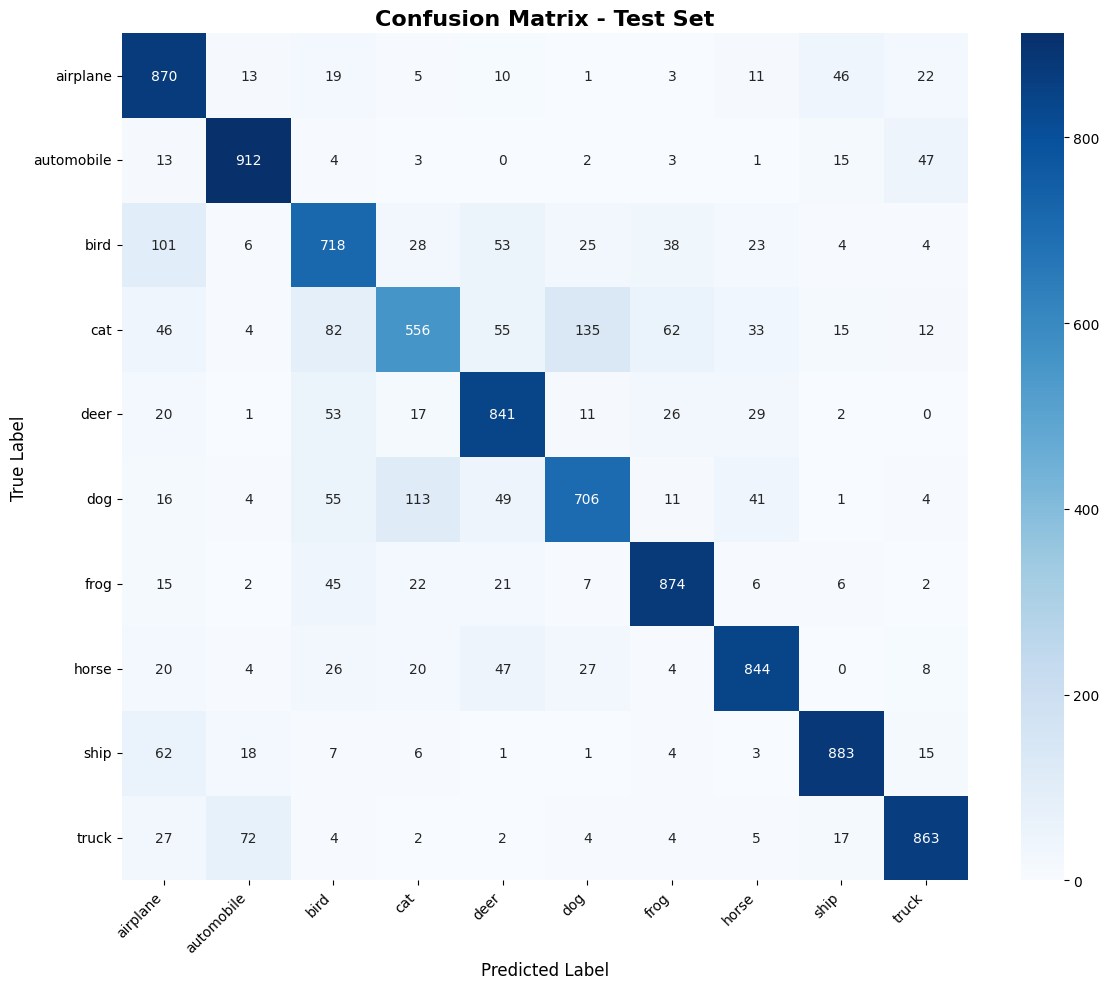

In [16]:
# Plot Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, test_loader, device, class_names):
  model.eval()
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = model(data)
      _, pred = torch.max(output.data, 1)
      all_preds.extend(pred.cpu().numpy())
      all_labels.extend(target.cpu().numpy())

  cm = confusion_matrix(all_labels, all_preds)

  plt.figure(figsize=(12, 10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
  plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
  plt.ylabel('True Label', fontsize=12)
  plt.xlabel('Predicted Label', fontsize=12)
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()
  return cm

class_names = cifar_test.classes
cm = plot_confusion_matrix(cifar_model, cifar_test_loader, device, class_names)

- **Strong diagonal dominance**: Most predictions align with true labels, indicating effective class discrimination across most categories

- **Key confusions**: Cat-Dog and Airplane-Bird pairs show the highest misclassification rates, reflecting shared visual features (fur texture/body shape for cats-dogs, flight poses/sky backgrounds for airplanes-birds)

In [17]:
# save pretrained weights
torch.save(cifar_model.state_dict(), 'cifar10_pretrained.pth')
print('Pretrained model saved to cifar10_pretrained.pth')

Pretrained model saved to cifar10_pretrained.pth


# Fine tuning on animal dataset

In [19]:
# Load animal dataset, normalize and augment
from dataset_util import dataset_split, calculate_normalization_stats, get_normalized_transforms

animal_ds_data_path = '/content/AnimalClassifier/animal_data'

# Load with basic transforms
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
full_animal_ds = datasets.ImageFolder(animal_ds_data_path, transform=basic_transform)

# Split 70/15/15
animal_train_ds, animal_val_ds, test_ds = dataset_split(full_animal_ds, 0.7, 0.15)

# Calculate stats from train
mean, std = calculate_normalization_stats(animal_train_ds)

# Augment on train, Normalize both
animal_train_transform = get_normalized_transforms(mean, std, augment=True)
animal_val_test_transform = get_normalized_transforms(mean, std, augment=False)

animal_train_full = datasets.ImageFolder(animal_ds_data_path, transform=animal_train_transform)
animal_val_full = datasets.ImageFolder(animal_ds_data_path, transform=animal_val_test_transform)
animal_test_full = datasets.ImageFolder(animal_ds_data_path, transform=animal_val_test_transform)

animal_train, _, _ = dataset_split(animal_train_full, 0.7, 0.15)
_, animal_val, _ = dataset_split(animal_val_full, 0.7, 0.15)
_, _, animal_test = dataset_split(animal_test_full, 0.7, 0.15)

**Lower learning rate in fine tuning for:**

- LR 0.0001 (vs 0.001 from scratch) allows gentle adaptation to our specific animal dataset while preserving transferable knowledge

- Prevent catastrophic forgetting of CIFAR-10 knowledge

**Architecture Adaptation:**

- Only conv layers transferred due to input dimension mismatch between CIFAR-10 (32×32) and animal dataset (224×224)

- CIFAR-10 model: 256×2×2=1024 features → FC layers, Animal model: 256×14×14=50176 features → FC layers

- Output layer adapted from 10 classes (CIFAR-10) to 15 classes (our animals)

- Conv filters learn patterns independent of spatial dimensions, making them perfectly transferable

**Increase epochs (and patience)**:

- Lower learning rate (0.0001 vs 0.001) requires more iterations to converge - each update makes smaller weight adjustments

- Fine-tuning adapts pretrained features gradually, needing extended training to properly adjust conv layers to new domain (224×224 animals vs 32×32 CIFAR-10)

- Increased to 100 epochs with patience=15 to allow sufficient time for convergence while maintaining early stopping protection against overfitting



In [22]:
# Fine tuning

print('Fine tuning on Animal Dataset')

input_size = 224
n_classes = 15
epochs = 100
patience = 15

model_finetune = CustomCNN(CONV, FC, input_size, n_classes, DROPOUT).to(device)

# Load pretrained weights
pretrained_dict = torch.load('cifar10_pretrained.pth')

# Filter out incompatible layers (FC and output layers have different sizes)
model_dict = model_finetune.state_dict()
pretrained_dict_filtered = {k: v for k, v in pretrained_dict.items()
                            if k.startswith('conv_layers') and k in model_dict and v.shape == model_dict[k].shape}

print(f'Loaded {len(pretrained_dict_filtered)}/{len(pretrained_dict)} layers from pretrained model')
print('Transferred layers:', list(pretrained_dict_filtered.keys()))
print()

# Load the filtered weights
model_finetune.load_state_dict(pretrained_dict_filtered, strict=False)

animal_train_loader = torch.utils.data.DataLoader(animal_train, batch_size=BATCH_SIZE, shuffle=True)
animal_val_loader = torch.utils.data.DataLoader(animal_val, batch_size=BATCH_SIZE, shuffle=False)
animal_test_loader = torch.utils.data.DataLoader(animal_test, batch_size=BATCH_SIZE, shuffle=False)

# Fine tune with lower learning rate
optimizer_finetune = torch.optim.Adam(model_finetune.parameters(), lr=0.0001, weight_decay=WEIGHT_DECAY)

model_fintune, history_finetune = train(model_finetune, animal_train_loader, animal_val_loader, optimizer_finetune, epochs, patience, device)

Fine tuning on Animal Dataset
Loaded 8/14 layers from pretrained model
Transferred layers: ['conv_layers.0.weight', 'conv_layers.0.bias', 'conv_layers.1.weight', 'conv_layers.1.bias', 'conv_layers.2.weight', 'conv_layers.2.bias', 'conv_layers.3.weight', 'conv_layers.3.bias']

Epoch 1/100 - Train Loss: 8.9035 - Train Acc: 0.0743 - Val Loss: 3.7260 - Val Acc: 0.1546
Epoch 5/100 - Train Loss: 2.5002 - Train Acc: 0.2191 - Val Loss: 2.2506 - Val Acc: 0.2612
Epoch 10/100 - Train Loss: 2.0119 - Train Acc: 0.3456 - Val Loss: 1.7900 - Val Acc: 0.4742
Epoch 15/100 - Train Loss: 1.5817 - Train Acc: 0.5221 - Val Loss: 1.3968 - Val Acc: 0.5601
Epoch 20/100 - Train Loss: 1.1824 - Train Acc: 0.6096 - Val Loss: 1.0735 - Val Acc: 0.6701
Epoch 25/100 - Train Loss: 0.8563 - Train Acc: 0.7176 - Val Loss: 0.8221 - Val Acc: 0.7560
Epoch 30/100 - Train Loss: 0.6399 - Train Acc: 0.7846 - Val Loss: 0.6795 - Val Acc: 0.8282
Epoch 35/100 - Train Loss: 0.5134 - Train Acc: 0.8390 - Val Loss: 0.5747 - Val Acc: 0.84

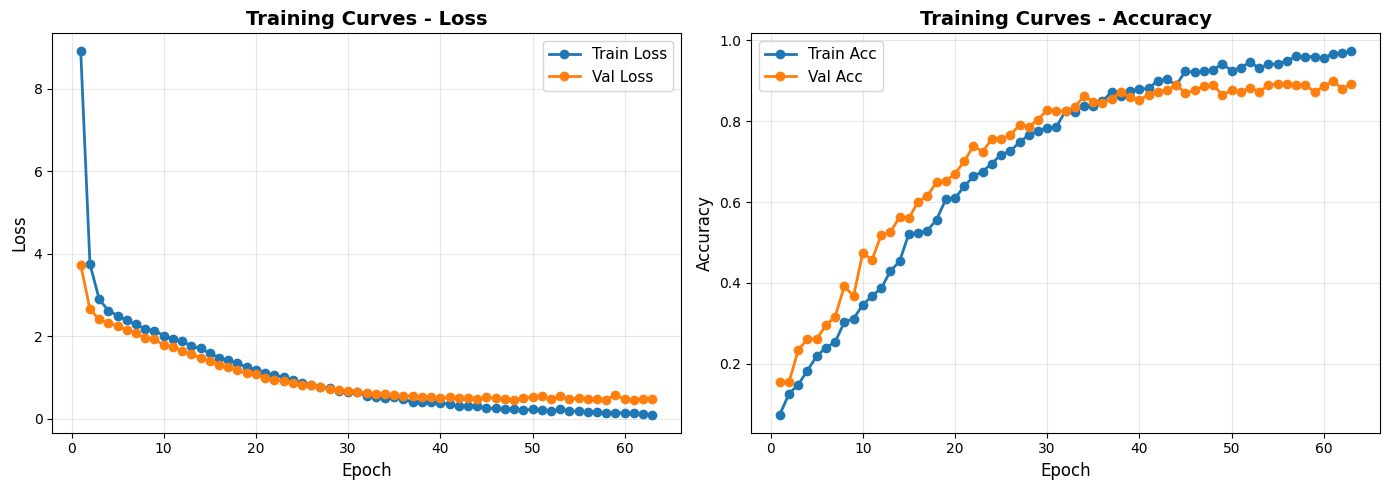

In [23]:
# Plot training curves

plot_training_curves(history_finetune)

The training curves show stable progress with only very minor fluctuations, and no significant overfitting is observed.

In [24]:
# Test Accuracy, Test Loss

test_loss, test_acc = evaluate(model_finetune, animal_test_loader, device)

print(f'Animal Test Loss: {test_loss:.4f}')
print(f'Animal Test Accuracy: {test_acc:.4f}')

Animal Test Loss: 0.2473
Animal Test Accuracy: 0.9352


Test Acc is about the same as from-scratch approach: 93.52/93.86

Test Loss in a bit better: 0.2473/0.390

The model achieved great performance and generalization

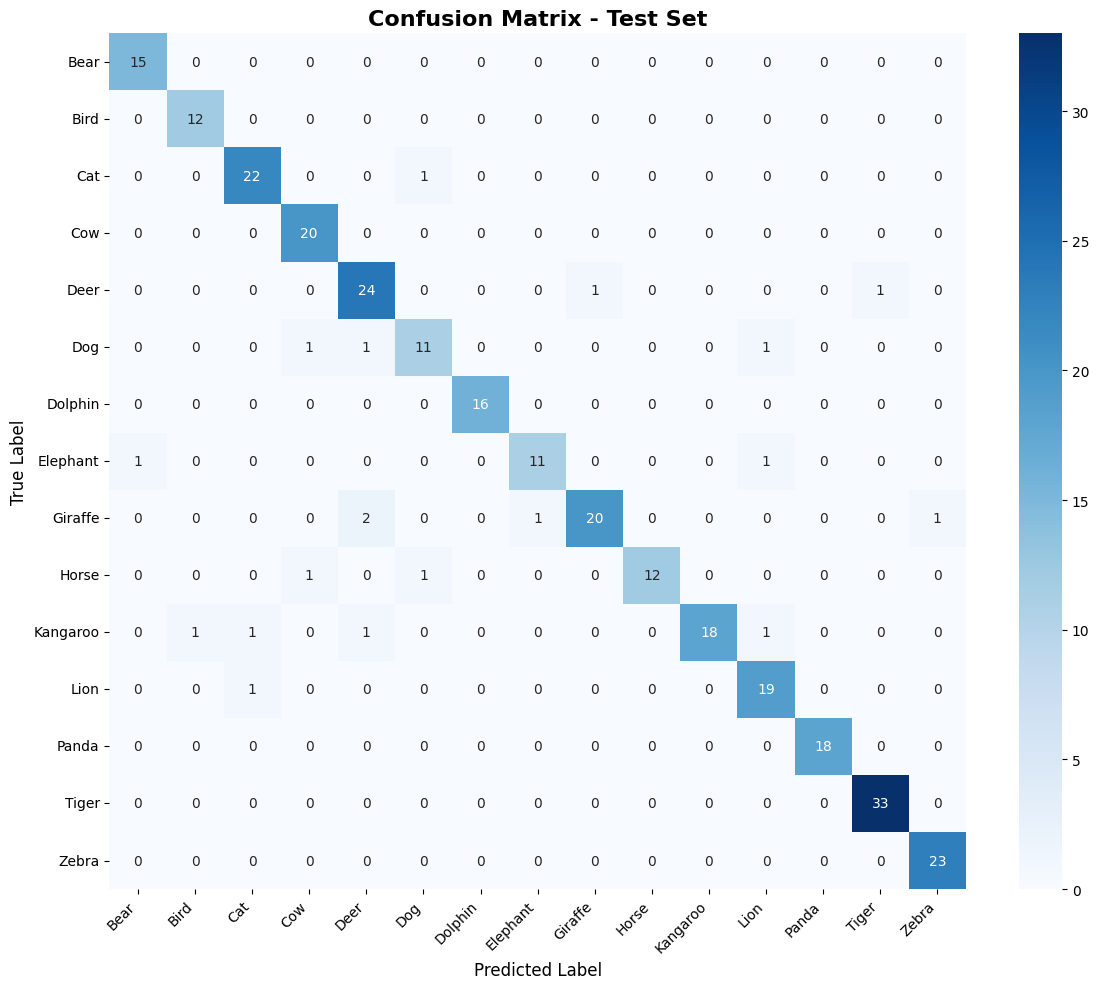

In [25]:
# Plot Confusion Matrix

animal_classes = full_animal_ds.classes
cm = plot_confusion_matrix(model_finetune, animal_test_loader, device, animal_classes)

- Strong diagonal dominance: Most predictions align with true labels, indicating effective class discrimination across all 15 animal categories

- Minimal inter-class confusion: Off-diagonal elements are sparse, confirming the model learned distinct features for each animal type

- Balanced performance: No single class shows severe misclassification, suggesting uniform model capability across the dataset

- Look about the same as from-scratch Confusion Matrix

## Transfer Learning vs From-Scratch: Comparison Analysis

### 1. Convergence Speed

**Epochs to Best Performance:**
- From-scratch: 25 epochs (early stop at 35)
- Transfer learning: 48 epochs (early stop at 63)
- **Result**: From-scratch converged **1.9× faster**

**Reason**: Higher LR (0.001 vs 0.0001) enabled faster convergence. Transfer learning's lower LR preserves pretrained features but requires more iterations to adapt from 32×32 CIFAR-10 to 224×224 animals.

---

### 2. Final Performance

| Metric | From-Scratch | Transfer Learning | Difference |
|--------|--------------|-------------------|------------|
| Val Accuracy | 95.19% | 89.35% | -5.84% |
| Test Accuracy | 93.86% | 93.52% | -0.34% |
| Test Loss | 0.390 | 0.247 | -0.143  |

**Key Findings:**
- Nearly identical test accuracy (0.34% difference)
- Transfer learning achieved better test loss (0.247 vs 0.390) - more confident predictions
- Large val-test discrepancy for transfer (89.35% -> 93.52%) suggests validation set had characteristics that challenged pretrained features

---

### 3. Generalization

**From-Scratch:**
- Train-val loss gap: ~0.12
- Val-test loss: 0.27 -> 0.390 (+0.12 increase)
- Consistent performance with slight test degradation

**Transfer Learning:**
- Train-val loss gap: Higher (moderate overfitting during training)
- Val-test loss: Better test loss (0.247) despite worse validation
- Superior loss calibration on test set indicates more robust probability estimates

**Key Insight**: Transfer learning achieved better test loss (0.247 vs 0.390) despite worse validation metrics, demonstrating stronger generalization to unseen data through pretrained feature representations.

---

### 4. Conclusions

**From-Scratch Advantages:**
- 1.9× faster convergence
- Better validation performance (95.19%)
- More efficient training

**Transfer Learning Advantages:**
- Comparable test accuracy (93.52%)
- Better loss calibration (0.247)
- More robust to data variations

**Why Transfer Learning Didn't Dominate:**
- Resolution mismatch (32×32 → 224×224)
- Domain gap (generic objects → animals)
- Small dataset (~700 images) with strong regularization sufficient for from-scratch training

**Final Verdict**: For this task, from-scratch training preferred due to efficiency and performance. Transfer learning would excel with much smaller datasets (<100 images/class).